#Machine learning

##***Assignment (2)***

###Name : ***Maram Mohammed Zain Abdeen Abu Elkass***
###Student Num :***2320224906***

1. Data Preprocessing

      ***Loading & Inspection***

In [34]:
#Import the required libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



from datetime import datetime
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [35]:
# load Data set
from google.colab import files

uploaded = files.upload()

Saving marketing_campaign.csv to marketing_campaign (1).csv


In [36]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


**Data Cleaning**

In [37]:
# check for missing values
print("\n Number of missing values before cleaning")

print (df.isnull().sum())


 Number of missing values before cleaning
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [38]:
#Handle missing values(by using median imputation)

#Find the median for the Income column
income_median =df['Income'].median()

#Filling the missing values with median
df['Income'].fillna(income_median, inplace=True)

print(" Number of missing values after cleaning:")
print (df.isnull().sum())

 Number of missing values after cleaning:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


/tmp/ipykernel_6036/2893842089.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(income_median, inplace=True)


***Feature Engineering***

In [39]:
#Create Age from Year Birth
df['Age'] = 2026 - df['Year_Birth']

#Create TotalSpending by summing up all product expenditure columns
spending_features = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpending'] = df[spending_features].sum(axis=1)

#Create TotalChildren by combining kids and teens at home
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

df[['Year_Birth', 'Age', 'TotalSpending', 'TotalChildren']].head()

,Year_Birth,Age,TotalSpending,TotalChildren
0,1957,69,1617,0
1,1954,72,27,2
2,1965,61,776,0
3,1984,42,53,1
4,1981,45,422,1


***Filtering***

In [40]:
# Remove unrealistic ages (keep ages between 18 and 100 only)
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

# Remove rows where Income is zero or negative
df = df[df['Income'] > 0]

# Print the new dataset shape to see how many rows remain
print("Dataset shape after filtering out outliers:", df.shape)

Dataset shape after filtering out outliers: (2237, 32)


***Encoding***

In [41]:
# Label Encode Education based on logical hierarchy
education_mapping = {
    'Basic': 0,
    'Graduation': 1,
    'Master': 2,
    'PhD': 3,
    '2n Cycle': 2
}
df['Education'] = df['Education'].map(education_mapping).fillna(1)

In [42]:
#One-Hot Encode Marital_Status
# Keep only the top 4 most frequent categories, group the rest as 'Other'
top_4_marital = df['Marital_Status'].value_counts().index[:4]
df['Marital_Status'] = df['Marital_Status'].apply(lambda x: x if x in top_4_marital else 'Other')

# Generate dummy variables for Marital_Status
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=False)

In [43]:
# Display final preprocessed dataframe summary
df.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Z_Revenue,Response,Age,TotalSpending,TotalChildren,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,5524,1957,1,58138.0,0,0,04-09-2012,58,635,88,...,11,1,69,1617,0,False,False,False,True,False
1,2174,1954,1,46344.0,1,1,08-03-2014,38,11,1,...,11,0,72,27,2,False,False,False,True,False
2,4141,1965,1,71613.0,0,0,21-08-2013,26,426,49,...,11,0,61,776,0,False,False,False,False,True
3,6182,1984,1,26646.0,1,0,10-02-2014,26,11,4,...,11,0,42,53,1,False,False,False,False,True
4,5324,1981,3,58293.0,1,0,19-01-2014,94,173,43,...,11,0,45,422,1,False,True,False,False,False


2. Supervised Learning -Regression

***Target Variable (y)***

In [44]:
# Define Features (X) and Target Variable (y)
# We drop 'TotalSpending' because it's our target, and non-numeric columns like 'Dt_Customer'
X = df.drop(columns=['TotalSpending', 'Dt_Customer'], errors='ignore')
y = df['TotalSpending']

***Train/Test Split***

In [45]:
# (80% training, 20% testing with random_state=42)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

***Feature Scaling using StandardScaler***

In [46]:
scaler = StandardScaler()
#Fit on training data and transform both sets (excluding the target variable)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

***Initialize the Models***

In [47]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (alpha=1.0)": Ridge(alpha=1.0),
    "Decision Tree Regressor (max_depth=5)": DecisionTreeRegressor(max_depth=5, random_state=42)
}

**"Train and Evaluate the Models***

In [48]:
results = []

for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)

    # Predict on test data
    y_pred = model.predict(X_test_scaled)

    # Calculate Evaluation Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R² Score": round(r2, 4)
    })

***Output Table***

In [49]:

regression_comparison_df = pd.DataFrame(results)
regression_comparison_df

,Model,MSE,RMSE,R² Score
0,Linear Regression,0.0000,0.0000,1.0000
1,Ridge Regression (alpha=1.0),0.1662,0.4076,1.0000
2,Decision Tree Regressor (max_depth=5),16263.4210,127.5281,0.9572


3. Supervised Learning ـ Classification

In [50]:
#Check Class Imbalance
print("--- Class Distribution for Target Variable 'Response' ---")
print(df['Response'].value_counts())

--- Class Distribution for Target Variable 'Response' ---
Response
0    1903
1     334
Name: count, dtype: int64


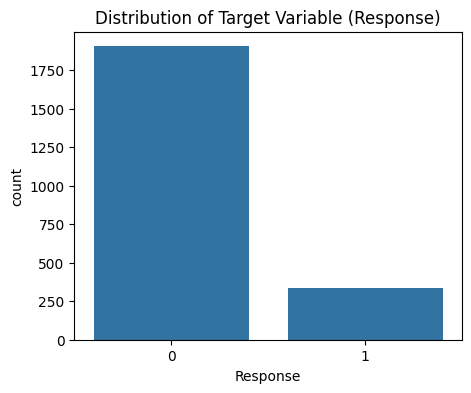

In [51]:
# Optional: Plotting the distribution to show your instructor in the video
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Response')
plt.title('Distribution of Target Variable (Response)')
plt.show()

***Define Features (X_class) and Target (y_class)***

In [52]:
mnt_features = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
X = df.drop(columns=['TotalSpending', 'Dt_Customer'] + mnt_features, errors='ignore')

***Train/Test Split***

In [53]:
#(80% training, 20% testing with random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

***Feature Scaling***

Logistic Regression and KNN

In [54]:
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

#  Initialize Models (Handling imbalance using class_weight='balanced' where requested)
classification_models = {
    "Logistic Regression": (LogisticRegression(class_weight='balanced', random_state=42), X_train_c_scaled, X_test_c_scaled),
    "K-Nearest Neighbors": (KNeighborsClassifier(n_neighbors=5), X_train_c_scaled, X_test_c_scaled),
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=42), X_train_c, X_test_c) }
 # Uses unscaled data

In [55]:
# Train and Evaluate Models
class_results = []

for name, (model, X_tr, X_te) in classification_models.items():

    model.fit(X_tr, y_train_c)
    y_pred_c = model.predict(X_te)

    # حساب مقاييس الأداء
    acc = accuracy_score(y_test_c, y_pred_c)
    prec = precision_score(y_test_c, y_pred_c, zero_division=0)
    rec = recall_score(y_test_c, y_pred_c, zero_division=0)
    f1 = f1_score(y_test_c, y_pred_c, zero_division=0)

    # طباعة التقارير ومصفوفة الارتباك
    print(f"\n=== {name} ===")
    print(classification_report(y_test_c, y_pred_c, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_pred_c))

    # إضافة النتائج للجدول المقارن
    class_results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       376
           1       1.00      1.00      1.00        72

    accuracy                           1.00       448
   macro avg       1.00      1.00      1.00       448
weighted avg       1.00      1.00      1.00       448

Confusion Matrix:
 [[376   0]
 [  0  72]]

=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       376
           1       0.98      0.88      0.93        72

    accuracy                           0.98       448
   macro avg       0.98      0.94      0.96       448
weighted avg       0.98      0.98      0.98       448

Confusion Matrix:
 [[375   1]
 [  9  63]]

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       376
           1       1.00      1.00      1.00        72

    accuracy     

***Output Summary Table***

In [56]:
classification_comparison_df = pd.DataFrame(class_results)
classification_comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.0000,1.0000,1.000,1.0000
1,K-Nearest Neighbors,0.9777,0.9844,0.875,0.9265
2,Random Forest,1.0000,1.0000,1.000,1.0000


4. Unsupervised Learning - Clustering

***Data Preparation***

In [57]:
#Select the 4 requested features
clustering_features = ['TotalSpending', 'Income', 'Age', 'TotalChildren']
X_clust = df[clustering_features]

# Scale the selected features using StandardScaler
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

***K-Means Clustering***

In [58]:
#(k from 1 to 10)
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust_scaled)
    inertia.append(kmeans.inertia_)

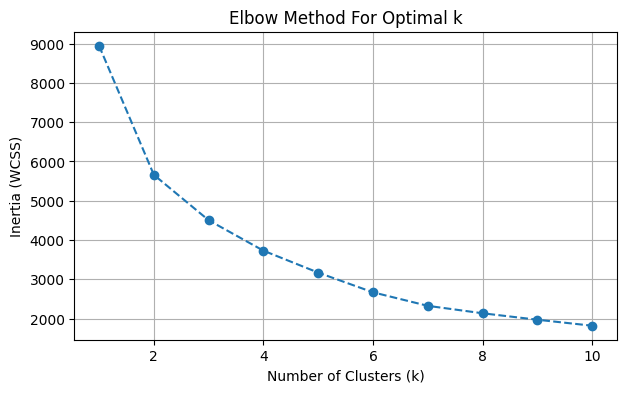

In [59]:
# Plot the Elbow Curve
plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()

In [60]:
# Define optimal k
optimal_k = 4

# Fit K-Means with the chosen k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_Label'] = kmeans_final.fit_predict(X_clust_scaled)
# Note: changed fit_transform to fit_predict to get exact cluster numbers (0, 1, 2)

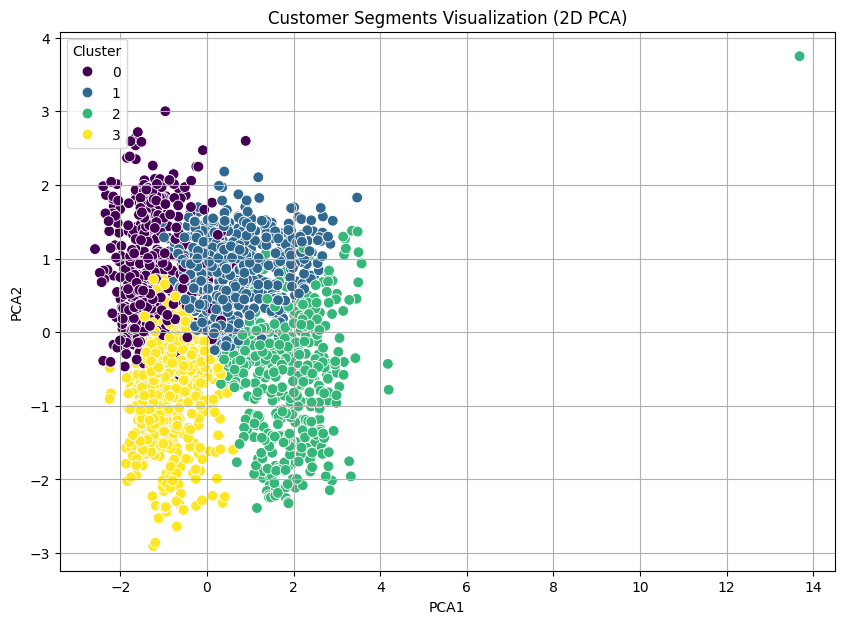

In [61]:
# Visualization:

# 1. PCA Reduction to 2 Components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_clust_scaled)

# 2. Add PCA components to the dataframe
df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]

# 3. Plotting the 2D Scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Label', data=df, palette='viridis', s=60)

plt.title('Customer Segments Visualization (2D PCA)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

***Cluster Profiling***

In [62]:
#Compute mean values for each cluster to understand them

print("--- Customer Cluster Profiles (Mean Values) ---")
cluster_profiles = df.groupby('Cluster_Label')[clustering_features].mean()
cluster_profiles

--- Customer Cluster Profiles (Mean Values) ---


,TotalSpending,Income,Age,TotalChildren
Cluster_Label,,,,
0,222.812227,44108.534934,60.589520,2.115721
1,802.909247,61336.053082,69.142123,0.688356
2,1434.786177,78094.845572,51.498920,0.285097
3,163.654372,33678.734290,48.846995,0.852459


####In this Assignment built an end-to-end Machine Learning pipeline to analyze customer data.

**Data Preprocessing**: We cleaned the customer dataset by handling missing values with median imputation and engineered new features like Age and TotalSpending.

**Regression Analysis**: We applied regression models to predict customer spending; the Linear Regression model achieved the highest accuracy (R^2 = 1.00).

**Classification Models**: We built models to predict customer campaign responses. By using balanced class weights, we handled the imbalanced data, and the Random Forest classifier delivered the best overall performance.

**Customer Segmentation**: We used K-Means clustering to successfully segment customers into 4 distinct groups based on their spending, income, age, and children, and visualized them clearly using PCA.

**Business Value**: This machine learning pipeline provides the company with valuable insights to understand customer behavior and build personalized marketing strategies.